<a href="https://colab.research.google.com/github/Kate-PSU/ArXive_TF-IDF_Zeroshot_term_extractor_classifier/blob/main/MY_term_extraction_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Подготовительный этап

In [ ]:
!pip install feedparser pandas scipy scikit-learn seaborn spacy torch torchvision transformers upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.4 MB/s eta 0:00:00
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24866 sha256=713c94d905e23d6a4ac8b5d2ff3d20ac33c02918bd136b3f07be8d6029018366
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=964a4591d9b764564278f286f9586f3f9ba37ce166af79a34612a6098d1a11ca
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built upsetplot sgmllib3k


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Загрузка аннотаций с arXiv

In [ ]:
import time
from pathlib import Path

import feedparser
import regex as re

In [ ]:
def query_arxiv(category: str, start: int, batch: int):
    url = (
        "http://export.arxiv.org/api/query?"
        f"search_query=cat:{category}&start={start}&max_results={batch}"
    )
    return feedparser.parse(url)

In [ ]:
def clean_text(text: str):
    # latex формулы $...$, $$...$$, \(...\), \[...\]
    text = re.sub(r"\${1,2}.*?\${1,2}", " ", text)
    text = re.sub(r"\\\(.*?\\\)", " ", text)
    text = re.sub(r"\\\[.*?\\\]", " ", text)
    # команды \command{...}
    text = re.sub(r"\\[a-zA-Z]+\{.*?\}", " ", text)
    # одиночные команды \alpha \textbf \frac и т.п.
    text = re.sub(r"\\[a-zA-Z]+", " ", text)
    # лишние фигурные скобки
    text = text.replace("{", " ").replace("}", " ")
    # двойные пробелы
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
def collect_for_category(
    out_dir: Path,
    label: str,
    arxiv_categories: list[str],
    *,
    limit_per_field: int = 800,
    batch: int = 200,
    interval_s: float = 3
):
    saved = 0

    out_path = out_dir / label
    out_path.mkdir(exist_ok=True, parents=True)

    print(f"\n=== Downloading: {label} ===")

    for cat in arxiv_categories:
        print(f"  -> category: {cat}")

        for start in range(0, limit_per_field, batch):
            feed = query_arxiv(cat, start, batch)

            if not feed.entries:
                break

            for entry in feed.entries:
                text = entry.summary.replace("\n", " ")
                text = clean_text(text)
                file_id = entry.id.split("/")[-1]
                fname = out_path / f"{file_id}.txt"
                fname.write_text(text)
                saved += 1

            print(f"    saved: {saved}")
            time.sleep(interval_s) # чтобы не поймать rate-limit

            if saved >= limit_per_field:
                break

    print(f"Total saved for {label}: {saved}")

In [ ]:
categories = {
    "machine_learning": ["cs.LG"],
    "cybersecurity": ["cs.CR"],
    "biology": ["q-bio"],
    "chemistry": ["physics.chem-ph", "chem"],
}

out_dir = Path('/content/drive/MyDrive/Data/Term-extraction/corpus')

In [ ]:
for label, categories in categories.items():
    collect_for_category(out_dir, label, categories)


=== Downloading: machine_learning ===
  -> category: cs.LG
    saved: 200
    saved: 400
    saved: 600
    saved: 800
Total saved for machine_learning: 800

=== Downloading: cybersecurity ===
  -> category: cs.CR
    saved: 200
    saved: 400
    saved: 600
    saved: 800
Total saved for cybersecurity: 800

=== Downloading: biology ===
  -> category: q-bio
    saved: 200
    saved: 400
    saved: 600
    saved: 800
Total saved for biology: 800

=== Downloading: chemistry ===
  -> category: physics.chem-ph
    saved: 200
    saved: 400
    saved: 600
    saved: 800
  -> category: chem
Total saved for chemistry: 800


## Извлечение терминов из текстов (TF-IDF)

In [ ]:
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

In [ ]:
src_dir = Path('/content/drive/MyDrive/Data/Term-extraction/corpus_2')

# Соберём все файлы по категориям
category_texts = {}

for filepath in src_dir.rglob('*.txt'):
    category = filepath.parent.name  # Название папки = категория
    text = filepath.read_text()
    category_texts.setdefault(category, []).append(text)

In [ ]:
# Загружаем Excel (лист "list")
acad_df = pd.read_excel('/content/acadCore.xlsx', sheet_name='list')

# Приводим все слова к нижнему регистру и превращаем в set
academic_stopwords = set(acad_df['word'].str.lower())


In [ ]:
import re,spacy

In [ ]:
# Загружаем модель spaCy
nlp = spacy.load("en_core_web_sm")

def is_valid_term(term):
    """
    1. Проверяет, что термин состоит только из слов (без цифр/символов)
    2. Лемматизирует
    3. Исключает, если все леммы — общенаучные
    """
    words = term.split()

    # Только буквы, минимум 2 символа
    if not all(re.fullmatch(r'[A-Za-z]{2,}', w) for w in words):
        return False

    # Лемматизация
    doc = nlp(term)
    lemmas = [token.lemma_.lower() for token in doc if token.is_alpha and len(token) >= 2]

    # Исключаем, если все леммы — в академических стоп-словах
    return not all(lemma in academic_stopwords for lemma in lemmas)


In [ ]:
# Извлекаем термины с TF-IDF, сохраняем веса
category_terms_weighted = {}

for category, texts in category_texts.items():
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.8,
        stop_words='english'
    )

    X = vectorizer.fit_transform(texts)
    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    # Получаем пары (термин, вес), сортируем по убыванию
    scored_terms = [(terms[i], scores[i]) for i in np.argsort(scores)[::-1]]

    # Фильтруем термины
    filtered_scored_terms = [
        (term, weight)
        for term, weight in scored_terms
        if is_valid_term(term)
    ][:3000]  # ограничение по количеству

    category_terms_weighted[category] = dict(filtered_scored_terms)  # пригодится для wordcloud


In [ ]:
df = pd.DataFrame([
    {"category": cat, "term": term, "tfidf": weight}
    for cat, terms in category_terms_weighted.items()
    for term, weight in terms.items()
])


In [ ]:
df

,category,term,tfidf
0,machine_learning,learning,0.029466
1,machine_learning,data,0.028290
2,machine_learning,training,0.016873
3,machine_learning,deep,0.015898
4,machine_learning,problem,0.013522
...,...,...,...
11995,chemistry,learning model,0.000405
11996,chemistry,dielectric permittivity,0.000404
11997,chemistry,heat transfer,0.000404
11998,chemistry,point view,0.000404


## Визуализация слов по категориям

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

In [ ]:
def plot_all_wordclouds(term_weight_dict, cols=2, width=800, height=400):
    """
    term_weight_dict — dict с категорией: {term: tfidf}
    cols — количество колонок на холсте
    """
    categories = list(term_weight_dict.keys())
    num_categories = len(categories)
    rows = math.ceil(num_categories / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    axes = axes.flatten()

    for i, category in enumerate(categories):
        wc = WordCloud(width=width, height=height, background_color='white').generate_from_frequencies(term_weight_dict[category])
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(category, fontsize=14)
        axes[i].axis("off")

    # Отключим лишние пустые оси
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


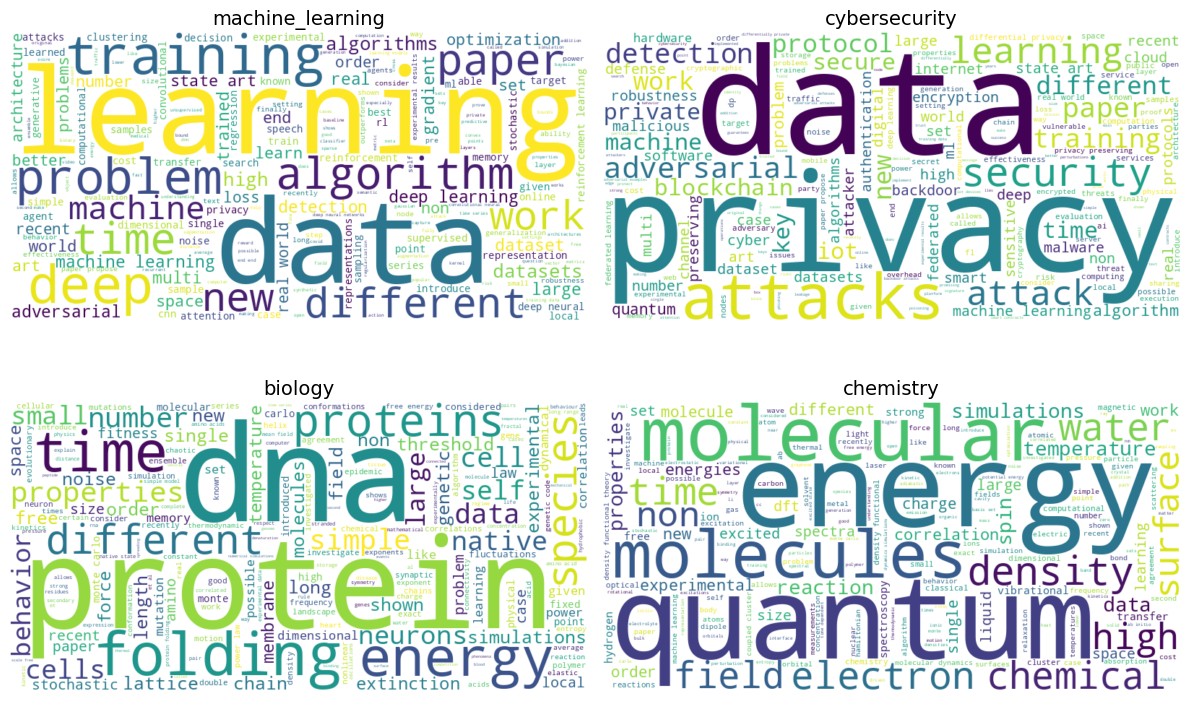

In [ ]:
plot_all_wordclouds(category_terms_weighted, cols=2)


In [ ]:
from itertools import zip_longest

# Группируем термины по категориям
grouped = df.groupby('category')['term'].apply(list)

# Убедимся, что это словарь с list-ами
category_dict = grouped.to_dict()

# Выровняем списки терминов до одинаковой длины
aligned_data = zip_longest(*category_dict.values())

# Создадим DataFrame
transposed_df = pd.DataFrame(aligned_data, columns=category_dict.keys())


In [ ]:
transposed_df

,biology,chemistry,cybersecurity,machine_learning
0,dna,energy,data,learning
1,protein,quantum,privacy,data
2,folding,molecular,attacks,training
3,time,molecules,security,deep
4,energy,density,learning,problem
...,...,...,...,...
2995,preserving,learning model,weakly,equivariance
2996,thermal denaturation,dielectric permittivity,certified robustness,proposed methodology
2997,cell growth,heat transfer,aggregator,algorithm provides
2998,adjustable parameters,point view,private function,non convex optimization


In [ ]:
transposed_df.to_excel('category_terms.xlsx', index=False)

In [ ]:
src_dir = Path('/content/drive/MyDrive/Data/Term-extraction/corpus')

texts = [file.read_text() for file in src_dir.rglob('*.txt')]
len(texts), texts[0]

vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    min_df=3,
    max_df=0.8,
    stop_words='english',
)
X = vectorizer.fit_transform(texts)
terms = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A.flatten()

TOP_K = 3000
idx = np.argsort(scores)[::-1][:TOP_K]
top_terms = [terms[i] for i in idx]
len(top_terms), top_terms[:10]

(3000,
 ['model',
  'data',
  'learning',
  'based',
  'models',
  'using',
  'network',
  'results',
  'time',
  'method'])

## Классификация терминов (zero-shot classification)

In [ ]:
import pandas as pd
from transformers import pipeline

In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidate_domains = ["machine learning", "cybersecurity", "biology", "chemistry"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
def classify_term(term):
    result = classifier(term, candidate_domains, multi_label=True)
    return {
        label: float(score)
        for label, score in zip(result["labels"], result["scores"])
        if score > 0.35
    }

In [ ]:
term_to_domain = {t: classify_term(t) for t in top_terms}
rows = []
for term, assignment in term_to_domain.items():
    rows.append(
        {
            "term": term,
            "machine_learning": "machine learning" in assignment,
            "cybersecurity": "cybersecurity" in assignment,
            "biology": "biology" in assignment,
            "chemistry": "chemistry" in assignment,
        }
    )

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
df = pd.DataFrame(rows)
df

,term,machine_learning,cybersecurity,biology,chemistry
0,model,True,True,False,False
1,data,True,True,False,False
2,learning,True,True,False,False
3,based,True,True,False,True
4,models,True,False,False,False
...,...,...,...,...,...
2995,regularized,False,True,False,False
2996,orientation,False,False,False,False
2997,redundancy,False,False,False,False
2998,outline,False,False,False,False


## Визуализация пересечений (диаграмма UpSet)

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

<Figure size 1000x600 with 0 Axes>

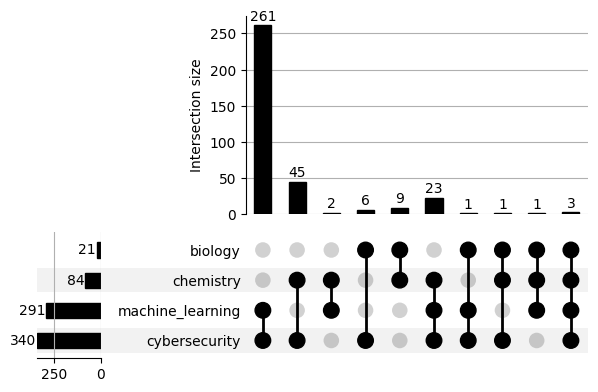

In [ ]:
domains = ["machine_learning", "cybersecurity", "biology", "chemistry"]

upset_data = from_indicators(
    domains,
    df[df[domains].sum(axis=1) > 1].astype(bool)
)
plt.figure(figsize=(10,6))
UpSet(upset_data, show_counts=True).plot()
plt.show()

## Визаулизация схожести областей (heatmap)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt


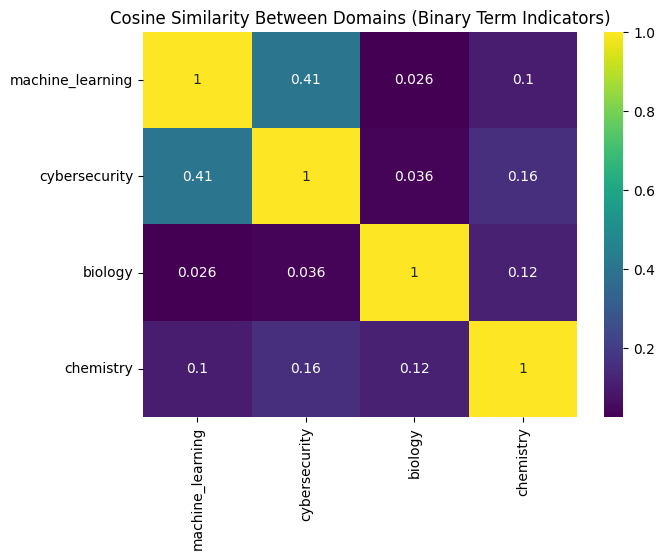

In [ ]:
indicator_df = df[domains].astype(int)

similarity_matrix = cosine_similarity(indicator_df.T)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=domains,
    columns=domains
)

plt.figure(figsize=(7, 5))
sns.heatmap(sim_df, annot=True, cmap="viridis")
plt.title("Cosine Similarity Between Domains (Binary Term Indicators)")
plt.show()

## Дерево предметных областей

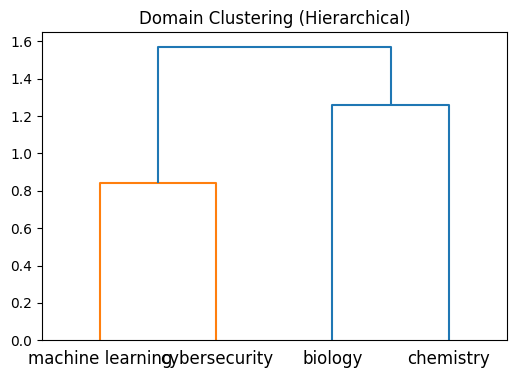

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(similarity_matrix, 'ward')

plt.figure(figsize=(6, 4))
dendrogram(linked, labels=candidate_domains)
plt.title("Domain Clustering (Hierarchical)")
plt.show()